17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000

Training RNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.6298 - loss: 0.6332 - val_accuracy: 0.7660 - val_loss: 0.4920
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 99ms/step - accuracy: 0.8345 - loss: 0.3756 - val_accuracy: 0.7266 - val_loss: 0.5564
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9365 - loss: 0.1773 - val_accuracy: 0.7576 - val_loss: 0.5813
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.9798 - loss: 0.0665 - val_accuracy: 0.7862 - val_loss: 0.6516
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 91ms/step - accuracy: 0.9949 - loss: 0.0208 - val_accuracy: 0.7772 - val_loss: 0.7841


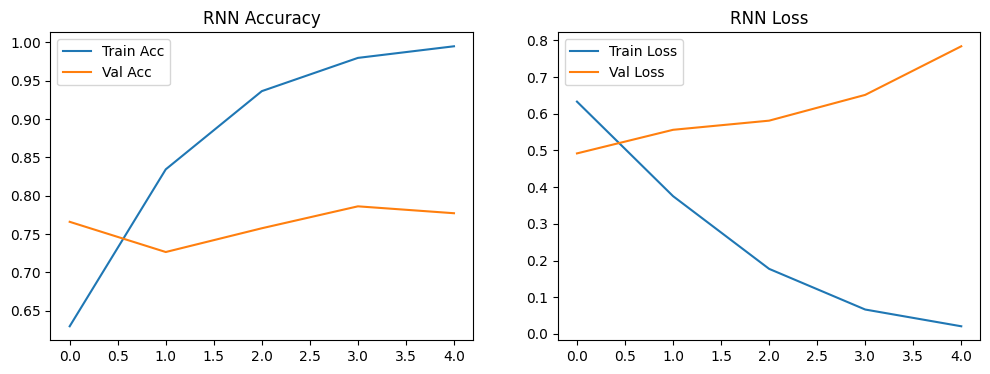


Training LSTM Model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 254ms/step - accuracy: 0.7921 - loss: 0.4374 - val_accuracy: 0.8712 - val_loss: 0.3084
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.9023 - loss: 0.2568 - val_accuracy: 0.8580 - val_loss: 0.3356
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 256ms/step - accuracy: 0.9323 - loss: 0.1833 - val_accuracy: 0.8736 - val_loss: 0.3416
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9504 - loss: 0.1404 - val_accuracy: 0.8678 - val_loss: 0.3780
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - accuracy: 0.9615 - loss: 0.1110 - val_accuracy: 0.8410 - val_loss: 0.4081


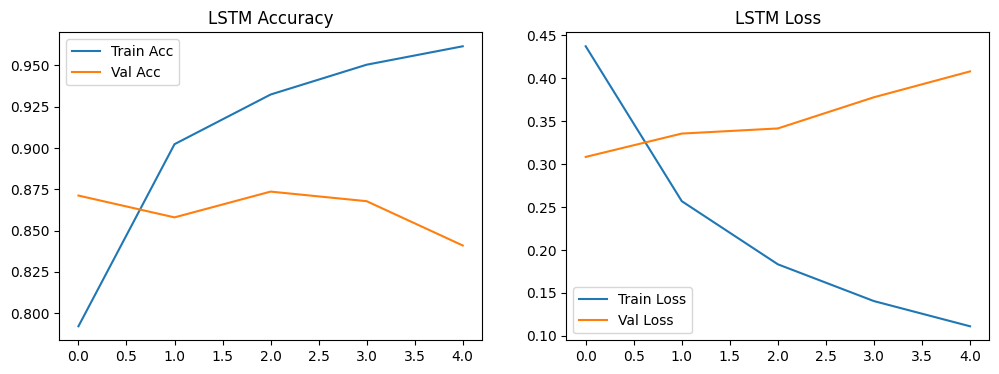


Training GRU Model...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 282ms/step - accuracy: 0.7724 - loss: 0.4606 - val_accuracy: 0.8262 - val_loss: 0.3912
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 271ms/step - accuracy: 0.8896 - loss: 0.2764 - val_accuracy: 0.8682 - val_loss: 0.3346
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 287ms/step - accuracy: 0.9315 - loss: 0.1895 - val_accuracy: 0.8628 - val_loss: 0.3497
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 295ms/step - accuracy: 0.9533 - loss: 0.1317 - val_accuracy: 0.8650 - val_loss: 0.3762
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 287ms/step - accuracy: 0.9686 - loss: 0.0916 - val_accuracy: 0.8630 - val_loss: 0.4148


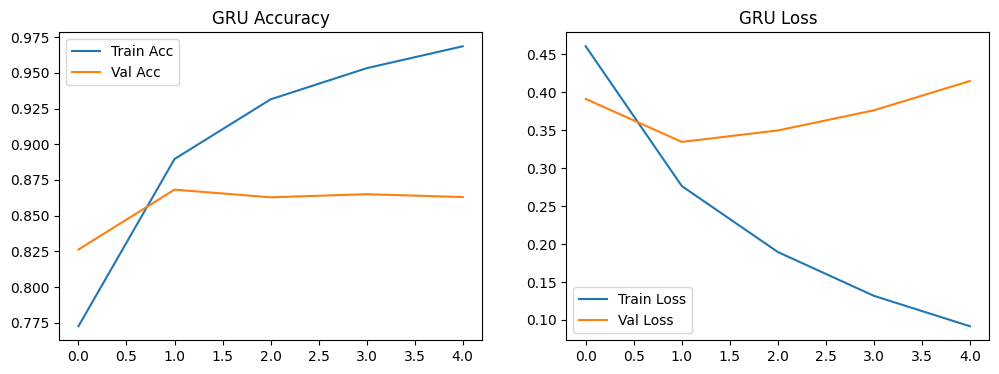


Evaluating Models...
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7764 - loss: 0.7757
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8374 - loss: 0.4132
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8574 - loss: 0.4286

Final Test Accuracy:
RNN  : 0.7764
LSTM : 0.8374
GRU  : 0.8574

Conclusion:
RNN struggles with long-term dependencies.
LSTM performs better due to memory cells.
GRU achieves similar performance with faster training.


In [1]:
# Experiment 6: Sequential Models – RNN, LSTM, GRU
# Objective: Compare RNN, LSTM, GRU on IMDb dataset

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU, Dropout

# -----------------------------
# Load and preprocess dataset
# -----------------------------
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))


# -----------------------------
# Plot learning curves
# -----------------------------
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()


# -----------------------------
# 1. RNN Model (Baseline)
# -----------------------------
print("\nTraining RNN Model...")

rnn_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_rnn, "RNN")


# -----------------------------
# 2. LSTM Model
# -----------------------------
print("\nTraining LSTM Model...")

lstm_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_lstm, "LSTM")


# -----------------------------
# 3. GRU Model
# -----------------------------
print("\nTraining GRU Model...")

gru_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    GRU(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

gru_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_gru = gru_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

plot_history(history_gru, "GRU")


# -----------------------------
# Evaluation
# -----------------------------
print("\nEvaluating Models...")

rnn_acc = rnn_model.evaluate(x_test, y_test)[1]
lstm_acc = lstm_model.evaluate(x_test, y_test)[1]
gru_acc = gru_model.evaluate(x_test, y_test)[1]

print("\nFinal Test Accuracy:")
print(f"RNN  : {rnn_acc:.4f}")
print(f"LSTM : {lstm_acc:.4f}")
print(f"GRU  : {gru_acc:.4f}")


# -----------------------------
# Conclusion
# -----------------------------
print("\nConclusion:")
print("RNN struggles with long-term dependencies.")
print("LSTM performs better due to memory cells.")
print("GRU achieves similar performance with faster training.")